# Chaîne OSF CAPC-AC — Notebook 01 · Observations de référence CHIRPS (phase P1)

**Objectif :** préparer la pluie observée qui servira à la fois de **prédictand** pour la calibration, de **référence** pour les seuils de catégories et d'**observation vérifiante**.

| Exigence du Draft Framework | Où dans ce notebook |
|---|---|
| §3.1.6 Contrôle qualité documenté avant tout usage | section 1 |
| §3.1.8 Harmonisation temporelle (mêmes périodes que les prévisions) | section 2 |
| §3.1.7 Harmonisation spatiale (grille commune avant tout calcul de biais ou de skill) | section 4 |
| D12 Seuils de catégories communs : normale observée 1991–2020, par point de grille | section 3 |
| §3.1.9 Incertitude observationnelle | section 5 (sensibilité à la période de référence) |

Les calculs lourds sont faits par l'étape opérationnelle `eccas_s2s.operations.obs_chirps` (notebook `OP_02`). Ce notebook **relit** ses résultats et les explique.

In [1]:
from pathlib import Path
import os, json
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
os.chdir(REPO)
from eccas_s2s.settings import load_cycle
from eccas_s2s.operations.obs_chirps import derived_paths, load_archives, load_normals
from eccas_s2s.core.periods import build_periods
from eccas_s2s.obs.climatology import obs_period_totals, normals_for_periods
from eccas_s2s.viz.maps import map_panel

cfg = load_cycle("config/cycle_202609.yaml")
SHP = cfg.raw["paths"]["shapefile"]
paths = derived_paths(cfg)
for k, p in paths.items():
    if k != "dir":
        print(f"{k:12s} {p.name:45s} {p.stat().st_size / 1e6:8.1f} Mo")

dekads_p05   chirps_p05_dekads_1981_2025.nc                  1389.2 Mo
months_p05   chirps_p05_months_1981_2025.nc                   557.5 Mo
dekads_1p0   chirps_1p0_dekads_1981_2025.nc                     5.7 Mo
months_1p0   chirps_1p0_months_1981_2025.nc                     2.1 Mo
normals_p05  chirps_p05_normals_1991_2020.nc                  676.0 Mo
normals_1p0  chirps_1p0_normals_1991_2020.nc                    2.4 Mo
qc           chirps_daily_qc_1981_2025.csv                      0.0 Mo


## 1. Contrôle qualité du fichier quotidien

Les fichiers CHIRPS v2.0 quotidiens (0,05°, **1981–2025**, boîte CEEAC) représentent environ 36 Go non compressés : le fichier 1991–2025 du CAPC-AC et les dix fichiers annuels 1981–1990 téléchargés pour couvrir la période de hindcast de NMME. Ils sont lus **mois par mois**, et chaque mois est contrôlé :

- jours présents contre jours attendus ;
- valeurs manquantes sur les mailles du domaine ;
- valeurs négatives ;
- maximum journalier, et nombre de valeurs supérieures à 300 mm/jour, qui sont plausibles localement mais doivent être examinées.

In [2]:
qc = pd.read_csv(paths["qc"])
print(f"{len(qc)} mois contrôlés ({qc.year.min()}–{qc.year.max()}), {int(qc.land_cells.iloc[0])} mailles dans le domaine")
summary = pd.Series({
    "mois incomplets": int((qc.days_present != qc.days_expected).sum()),
    "valeurs manquantes sur le domaine": int(qc.missing_land_values.sum()),
    "valeurs négatives": int(qc.negative_values.sum()),
    "valeurs > 300 mm/j": int(qc.suspicious_values.sum()),
    "maximum journalier (mm)": round(float(qc.max_daily_mm.max()), 1),
})
summary.to_frame("bilan")

540 mois contrôlés (1981–2025), 475231 mailles dans le domaine


,bilan
mois incomplets,0.0
valeurs manquantes sur le domaine,0.0
valeurs négatives,0.0
valeurs > 300 mm/j,107.0
maximum journalier (mm),490.7


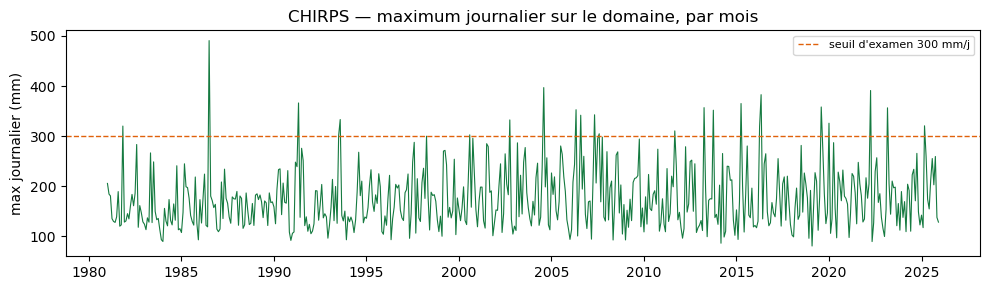

In [3]:
fig, ax = plt.subplots(figsize=(10, 3))
t = pd.to_datetime(dict(year=qc.year, month=qc.month, day=1))
ax.plot(t, qc.max_daily_mm, lw=0.8, color="#157A40")
ax.axhline(300, color="#E0610B", ls="--", lw=1, label="seuil d'examen 300 mm/j")
ax.set_ylabel("max journalier (mm)"); ax.set_title("CHIRPS — maximum journalier sur le domaine, par mois")
ax.legend(fontsize=8); plt.tight_layout()

In [4]:
qc[qc.suspicious_values > 0].sort_values("max_daily_mm", ascending=False).head(8)

,year,month,days_expected,days_present,missing_land_values,negative_values,max_daily_mm,suspicious_values,land_cells
66,1986,7,31,31,0,0,490.678162,9,475231
283,2004,8,31,31,0,0,396.879730,7,475231
495,2022,4,30,30,0,0,391.090637,30,475231
424,2016,5,31,31,0,0,382.781921,4,475231
124,1991,5,31,31,0,0,366.243073,2,475231
411,2015,4,30,30,0,0,365.069977,1,475231
463,2019,8,31,31,0,0,358.197632,11,475231
387,2013,4,30,30,0,0,356.882874,9,475231


**Lecture.** Le fichier est complet : aucun jour manquant, aucune valeur manquante sur le domaine, aucune valeur négative. Les quelques valeurs supérieures à 300 mm/jour sont des cas isolés. Elles ne sont pas corrigées : CHIRPS est un produit fusionné satellite + stations, et une correction manuelle irait contre l'objectivité de la chaîne. Elles sont documentées ici et dans le manifeste.

## 2. Cumuls calendaires et périodes du cycle

Les cumuls **décadaires** (1–10, 11–20, 21–fin) et **mensuels** sont calculés une seule fois pour 1991–2025 et archivés. Un cycle de prévision **sélectionne** ensuite ses périodes. Un cumul n'est défini que si **tous** les jours sont présents (`skipna=False`) : on ne complète jamais un cumul incomplet.

Les saisons sont la somme de trois mois. Une saison à cheval sur deux années, comme DJF 2025-26, prend décembre de l'année Y, puis janvier et février de Y+1.

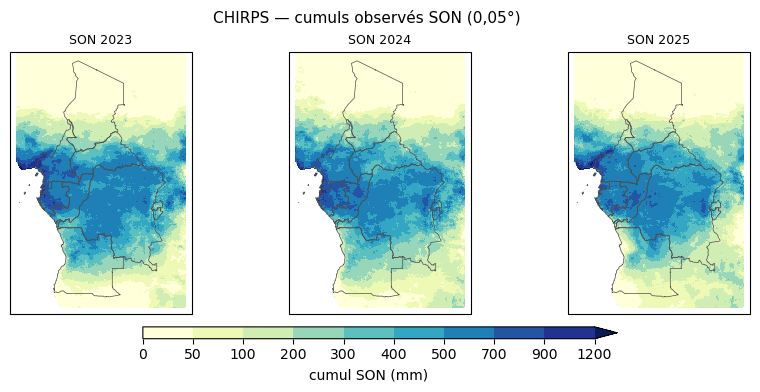

In [5]:
dek, mon = load_archives(cfg, "p05")
periods = build_periods(cfg.init_date, 181, cfg.scales)
son = [p for p in periods if p.key == "season_m0"]
obs_son = obs_period_totals(dek, mon, son, years=[2023, 2024, 2025]).sel(period="season_m0")
fig = map_panel([obs_son.sel(year=y) for y in (2023, 2024, 2025)],
                [f"SON {y}" for y in (2023, 2024, 2025)], shapefile=SHP, cmap="YlGnBu",
                levels=[0, 50, 100, 200, 300, 400, 500, 700, 900, 1200], extend="max",
                cbar_label="cumul SON (mm)", suptitle="CHIRPS — cumuls observés SON (0,05°)")

## 3. Normales 1991–2020 par point de grille (décision D12)

Pour chaque maille et chacune des 60 périodes calendaires (36 décades, 12 mois, 12 saisons), l'échantillon est formé des **30 cumuls observés** de 1991 à 2020. On en tire :

- la moyenne et l'écart-type ;
- les percentiles **P5, P10, P20, P33, P50, P67, P80, P90, P95** ;
- le nombre d'années valides ; une maille qui en a moins de 25 est laissée vide.

**Estimateur des percentiles.** Sur 30 valeurs, la définition du percentile compte. On utilise la **position de Weibull** : la *k*-ième valeur classée correspond à la probabilité *k/(n+1)*. Ce choix classique en climatologie et en hydrologie donne des probabilités sans biais, ce qui garantit qu'on attend en moyenne 1/3 des années dans chaque tercile.

Ces seuils sont **communs à tous les modèles** (C3S et NMME) : un « au-dessus de la normale » a le même sens partout. Pendant la validation croisée, ils seront recalculés sans l'année vérifiée (phase P3).

In [6]:
norm = load_normals(cfg, "p05")
print(norm)

<xarray.Dataset> Size: 1GB
Dimensions:       (calendar_key: 60, latitude: 900, longitude: 600,
                   percentile: 9)
Coordinates:
  * calendar_key  (calendar_key) <U10 2kB 'dekad_01_1' ... 'season_12'
  * percentile    (percentile) float64 72B 5.0 10.0 20.0 ... 80.0 90.0 95.0
  * latitude      (latitude) float64 7kB -19.98 -19.93 -19.88 ... 24.93 24.98
  * longitude     (longitude) float64 5kB 5.025 5.075 5.125 ... 34.92 34.98
Data variables:
    mean          (calendar_key, latitude, longitude) float32 130MB ...
    std           (calendar_key, latitude, longitude) float32 130MB ...
    n_years       (calendar_key, latitude, longitude) int16 65MB ...
    quantile      (percentile, calendar_key, latitude, longitude) float32 1GB ...
Attributes: (12/13)
    normal_period:      1991-2020
    percentile_method:  weibull
    min_years:          25
    source_signature:   /home/ludric/Downloads/SVM/Previsions_S2S/DATA_OSF/ra...
    source_files:       /home/ludric/Downloads/SVM/P

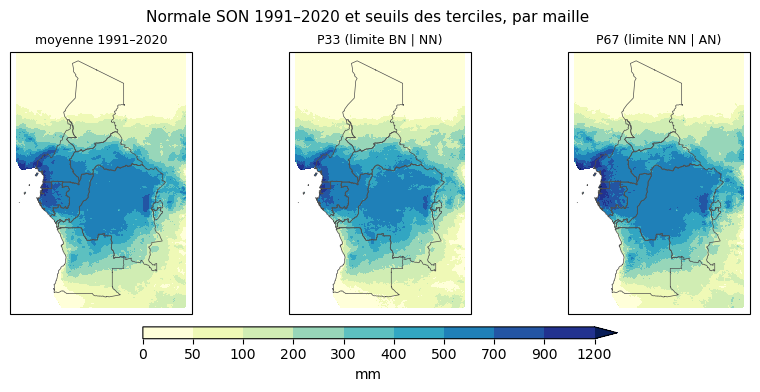

In [7]:
ns = normals_for_periods(norm, son).sel(period="season_m0")
fig = map_panel([ns["mean"], ns["quantile"].sel(percentile=33.333333, method="nearest"),
                 ns["quantile"].sel(percentile=66.666667, method="nearest")],
                ["moyenne 1991–2020", "P33 (limite BN | NN)", "P67 (limite NN | AN)"],
                shapefile=SHP, cmap="YlGnBu", levels=[0, 50, 100, 200, 300, 400, 500, 700, 900, 1200],
                extend="max", cbar_label="mm", suptitle="Normale SON 1991–2020 et seuils des terciles, par maille")

**Pourquoi par maille ?** Un même cumul de 300 mm en SON est « au-dessous de la normale » sur le plateau camerounais et « au-dessus » au Tchad. Des seuils calculés maille par maille donnent aux catégories un sens local homogène sur tout le domaine.

### Masque de saison sèche

Quand il ne pleut presque pas, les catégories n'ont plus de sens : beaucoup d'années valent 0 mm, et P33 comme P67 peuvent être nuls. Les produits masquent donc les mailles « sèches ». Le masque est **paramétrable** (`thresholds.yaml`, `precip.dry_mask`, ou à l'exécution) :

| Méthode | Une maille est masquée si la pluie **prévue** de la période est… | Valeur par défaut |
|---|---|---|
| `relative` (défaut) | inférieure à une fraction de la moyenne climatologique de la maille | 15 % |
| `absolute` | inférieure à un seuil fixe | 5 mm (décade), 15 mm (mois), 45 mm (saison) |

La pluie prévue est la moyenne d'ensemble pour les produits bruts, et la médiane de la distribution calibrée pour les produits calibrés. La climatologie est celle du modèle pour les produits bruts, et la normale observée 1991–2020 pour les produits calibrés.

Illustration avec la pluie **observée** de la 1ʳᵉ décade de janvier 2025, traitée comme si c'était une prévision :

relative (< 15 % de la normale)  :   36 % du domaine masqué
absolute (< 5 mm)                :   60 % du domaine masqué


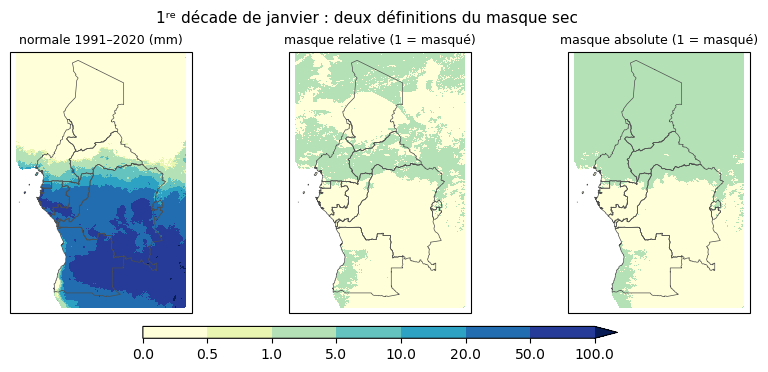

In [8]:
from eccas_s2s.products.masks import dry_mask, dry_mask_settings
key = "dekad_01_1"
pseudo_forecast = dek.sel(time="2025-01-01")
normal_mean = norm["mean"].sel(calendar_key=key)
m_rel = dry_mask(pseudo_forecast, dry_mask_settings(cfg.thresholds, method="relative"), normal_mean)
m_abs = dry_mask(pseudo_forecast, dry_mask_settings(cfg.thresholds, method="absolute"), scale="decade")
dom = pseudo_forecast.notnull()
for name, m in (("relative (< 15 % de la normale)", m_rel), ("absolute (< 5 mm)", m_abs)):
    print(f"{name:32s} : {float(m.where(dom).mean()) * 100:4.0f} % du domaine masqué")
fig = map_panel([normal_mean, m_rel.where(dom).astype(float), m_abs.where(dom).astype(float)],
                ["normale 1991–2020 (mm)", "masque relative (1 = masqué)", "masque absolute (1 = masqué)"],
                shapefile=SHP, cmap="YlGnBu", levels=[0, 0.5, 1, 5, 10, 20, 50, 100], extend="max",
                suptitle="1ʳᵉ décade de janvier : deux définitions du masque sec")

Les deux méthodes ne masquent pas les mêmes régions. Le seuil **absolu** (5 mm) masque tout le nord du domaine, y compris des mailles où 5 mm représentent une décade normale. Le seuil **relatif** (15 % de la normale de la maille) ne masque que les mailles où la pluie prévue est réellement faible **pour cet endroit et cette période**, et reste donc utilisable dans les régions sèches. C'est pourquoi il est retenu par défaut.

## 4. Harmonisation spatiale : de 0,05° à 1°

Les modèles C3S sont sur une grille de 1° dont les centres sont à x,5°. La grille CHIRPS a des bords sur les degrés entiers (−20° … 25°, 5° … 35°) : chaque maille de 1° contient **exactement 20 × 20 mailles CHIRPS**. Le passage à 1° est donc une **moyenne par blocs exacte**, sans interpolation. Le code vérifie cet emboîtement et refuse une grille décalée.

Une maille de 1° est laissée vide si moins de la moitié de ses mailles CHIRPS sont valides (côtes, grands lacs).

La grille à 1° sert aux **diagnostics** (biais, skill brut), qui comparent modèle et observation sur la même grille (§3.1.7). Les produits calibrés, eux, seront rendus à **0,05°** (décision D3).

moyenne pondérée 0,05° : 83.01 mm | 1° : 82.92 mm


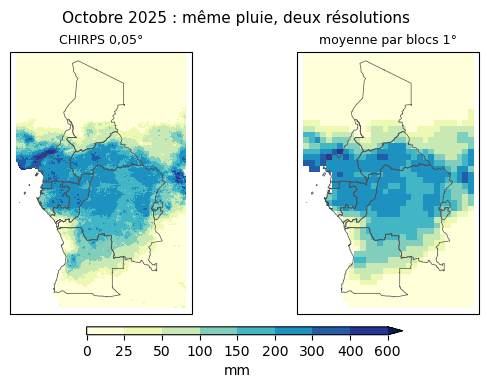

In [9]:
dek1, mon1 = load_archives(cfg, "1p0")
o05 = mon.sel(time="2025-10-01"); o1 = mon1.sel(time="2025-10-01")
fig = map_panel([o05, o1], ["CHIRPS 0,05°", "moyenne par blocs 1°"], shapefile=SHP, cmap="YlGnBu",
                levels=[0, 25, 50, 100, 150, 200, 300, 400, 600], extend="max", cbar_label="mm",
                suptitle="Octobre 2025 : même pluie, deux résolutions")
# contrôle : la moyenne de domaine est conservée
w05 = np.cos(np.deg2rad(o05.latitude)); w1 = np.cos(np.deg2rad(o1.latitude))
print("moyenne pondérée 0,05° :", round(float(o05.weighted(w05).mean()), 2),
      "mm | 1° :", round(float(o1.weighted(w1).mean()), 2), "mm")

Les deux moyennes de domaine sont très proches. Le petit écart vient seulement des mailles côtières vides à 1°.

## 5. Sensibilité à la période de référence

Les seuils de catégories utilisent la normale **1991–2020** (D12), alors que les modèles C3S sont ajustés sur **1993–2016**. La calibration produit une distribution dans l'espace des observations : on peut donc lui appliquer n'importe quels seuils observés. Mais il est utile de voir combien les deux climatologies diffèrent, car c'est une forme d'incertitude observationnelle (§3.1.9) :

écart médian : 1.2 % ; 95e centile : 6.2 %


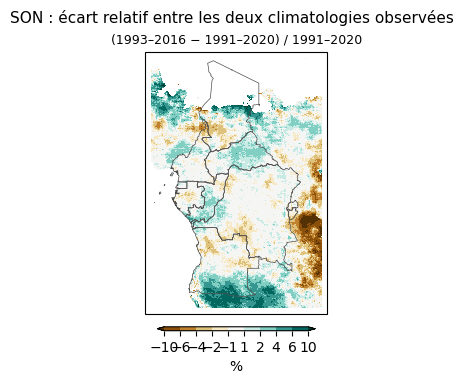

In [10]:
key = son[0].calendar_key
m9120 = norm["mean"].sel(calendar_key=key)
sample = xr.concat([mon.sel(time=[f"{y}-09-01", f"{y}-10-01", f"{y}-11-01"]).sum("time", skipna=False)
                    for y in range(1993, 2017)], dim="year")
m9316 = sample.mean("year")
rel = (m9316 - m9120) / m9120.where(m9120 > 10) * 100
fig = map_panel([rel], ["(1993–2016 − 1991–2020) / 1991–2020"], shapefile=SHP, cmap="BrBG",
                levels=[-10, -6, -4, -2, -1, 1, 2, 4, 6, 10], cbar_label="%",
                suptitle="SON : écart relatif entre les deux climatologies observées")
print("écart médian :", round(float(abs(rel).median()), 1), "% ; 95e centile :", round(float(abs(rel).quantile(0.95)), 1), "%")

## Récapitulatif

| Produit dérivé | Résolution | Usage |
|---|---|---|
| cumuls décadaires et mensuels 1991–2025 | 0,05° et 1° | prédictand, observation vérifiante |
| normales 1991–2020 (moyenne, écart-type, 9 percentiles) | 0,05° et 1° | seuils communs des catégories, anomalies observées |
| contrôle qualité mensuel | — | traçabilité (§3.1.6) |

L'archive couvre **1981–2025**, ce qui permet de calibrer NMME sur toute sa période de hindcast (depuis 1982) comme le demande la décision D4.

Notebook suivant : `02_cumuls_c3s.ipynb`, les cumuls des modèles et un premier regard sur leurs biais.